<a href="https://colab.research.google.com/github/agajinformatica/Vision_por_computadora/blob/main/S02_Representacion_Operaciones_Pixeles_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visión por Computadora
## Clase 2 — Representación digital y operaciones sobre píxeles
### Unidad 1 · Fundamentos y características visuales

**Laboratorio práctico (Google Colab).** En la clase anterior entendiste que una imagen es
una **tabla de números**. Hoy vamos a **operar** sobre esos números: leer el histograma,
cambiar brillo y contraste, ecualizar, umbralizar y —lo más importante para el resto del
curso— **normalizar** una imagen para alimentar un modelo de deep learning.

---

#### Cómo trabajar en este notebook

1. Ejecuta las celdas **en orden**, de arriba hacia abajo, con el botón ▶ o con `Shift + Enter`.
2. Cada tema sigue el mismo camino: **primero un ejemplo minúsculo con números** (una matriz
   de 3×3 que puedes seguir con la vista) y **luego el mismo efecto sobre una imagen real**.
   Así entiendes *qué* hace la operación antes de verla sobre una foto.
3. No necesitas instalar nada: Colab ya trae todo.



---
## Parte 0 · Preparación

Cargamos las librerías que usaremos. En Colab ya vienen instaladas, así que esto es
instantáneo. Solo las "traemos" a nuestro programa con `import`.

In [1]:
# ----------------------------------------------------------------------------
# Cada 'import' trae una librería (una caja de herramientas ya hecha).
# La palabra reservada "as" le pone un apodo corto para escribir menos.
# ----------------------------------------------------------------------------
import cv2                       # OpenCV: la librería de visión por computadora
import numpy as np               # NumPy: maneja tablas de números (así se guarda una imagen)
import matplotlib.pyplot as plt  # Matplotlib: para dibujar imágenes y gráficos

# Esta línea es especial de Colab/Jupyter: hace que los gráficos aparezcan
# DENTRO del notebook, justo debajo de cada celda (y no en una ventana aparte).
%matplotlib inline

print("Todo listo. Las librerías se cargaron correctamente.")  # aviso de que ya podemos seguir

Todo listo. Las librerías se cargaron correctamente.


---
## Parte 1 · Recordatorio: una imagen es una tabla de números

Antes de tocar una foto, veamos la idea en su versión más pequeña posible: una imagen
de apenas **3×3 = 9 píxeles**. Cada número es la intensidad de un punto:
**0 = negro**, **255 = blanco**, y los valores intermedios son grises.

Nuestra mini-imagen como números:
[[ 20 120 220]
 [ 60 130 200]
 [ 10 128 250]]

Tamaño (filas, columnas): (3, 3)


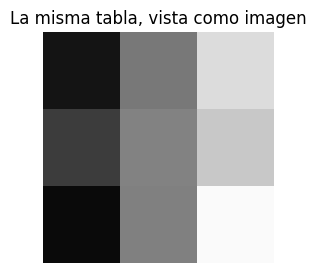

In [2]:
# np.array crea una "tabla" (matriz) de números a partir de la lista que le damos.
# dtype=np.uint8 significa "enteros de 0 a 255", que es el rango de un píxel.
mini = np.array([[ 20, 120, 220],     # fila 0: un tono oscuro, uno medio, uno claro
                 [ 60, 130, 200],     # fila 1
                 [ 10, 128, 250]],    # fila 2
                dtype=np.uint8)

print("Nuestra mini-imagen como números:")
print(mini)                            # la mostramos tal cual: 3 filas x 3 columnas

# .shape nos dice el tamaño: (filas, columnas). Aquí será (3, 3).
print("\nTamaño (filas, columnas):", mini.shape)

# Ahora dibujamos esos mismos números como tonos de gris:
plt.figure(figsize=(3, 3))             # figura pequeña de 3x3 pulgadas
plt.imshow(mini, cmap="gray", vmin=0, vmax=255)  # cmap="gray": pinta el número como gris
                                        # vmin/vmax: fija que 0=negro y 255=blanco siempre
plt.title("La misma tabla, vista como imagen")
plt.axis("off")                        # ocultamos los ejes con números (no aportan aquí)
plt.show()                             # mostramos la figura

**Lo que acabas de ver:** a la izquierda (el `print`) están los números; el dibujo es
*exactamente* esos mismos números pintados como grises. Para la computadora, la imagen
**son** los números. Todo lo de hoy es hacer cuentas con ellos.

---
## Parte 2 · La imagen con la que vas a trabajar

De aquí en adelante usaremos una imagen más grande.


### Subir tu propia foto

Cuando quieras trabajar con **tu** imagen, ejecuta la celda de abajo. Se abrirá un botón
para elegir un archivo de tu computadora. Al terminar, la variable `work_gray` pasará a ser
tu foto en escala de grises, y **todas las celdas siguientes usarán tu imagen**.

Si prefieres seguir con la de ejemplo, **salta esta celda** (no la ejecutes) y continúa.

Saving IMG_9904.jpg to IMG_9904 (2).jpg


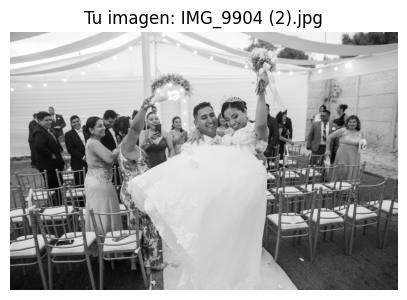

¡Listo! A partir de ahora se usará tu imagen. Tamaño: (3648, 5472)


In [5]:
# ----------------------------------------------------------------------------
# SUBIDA DE ARCHIVO EN COLAB
# 'google.colab.files' solo existe en Colab; por eso lo importamos aquí dentro.
# ----------------------------------------------------------------------------
from google.colab import files          # herramienta de Colab para subir/bajar archivos

subidos = files.upload()                # abre el botón "Elegir archivos"; devuelve un diccionario:
                                        #   { "nombre_del_archivo": bytes_del_archivo }

if len(subidos) == 0:                    # si no elegiste ningún archivo...
    print("No subiste ninguna imagen.")
else:
    nombre = list(subidos.keys())[0]     # tomamos el nombre del primer (y único) archivo
    datos = subidos[nombre]              # los bytes crudos de ese archivo

    # np.frombuffer convierte esos bytes en una lista de números (todavía no es una imagen):
    buffer = np.frombuffer(datos, dtype=np.uint8)

    # cv2.imdecode interpreta esos números y arma la imagen a color (en orden BGR de OpenCV):
    img_color = cv2.imdecode(buffer, cv2.IMREAD_COLOR)

    # cv2.cvtColor convierte de color a escala de grises (una sola capa de intensidad):
    work_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # Mostramos tu imagen ya en grises:
    plt.figure(figsize=(5, 4))
    plt.imshow(work_gray, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Tu imagen: {nombre}")
    plt.axis("off")
    plt.show()
    print("¡Listo! A partir de ahora se usará tu imagen. Tamaño:", work_gray.shape)

---
## Parte 3 · El histograma: la "huella" de la imagen

El histograma es un gráfico de barras que **cuenta cuántos píxeles hay de cada tono**
(de 0 a 255). Sirve para diagnosticar la imagen sin mirarla: ¿es oscura, clara o plana?

**Primero, con la mini-imagen** para entender qué se está contando.

Los 9 valores de la mini-imagen, en fila: [ 20 120 220  60 130 200  10 128 250]
  el tono  10 aparece 1 vez/veces
  el tono  20 aparece 1 vez/veces
  el tono  60 aparece 1 vez/veces
  el tono 120 aparece 1 vez/veces
  el tono 128 aparece 1 vez/veces
  el tono 130 aparece 1 vez/veces
  el tono 200 aparece 1 vez/veces
  el tono 220 aparece 1 vez/veces
  el tono 250 aparece 1 vez/veces


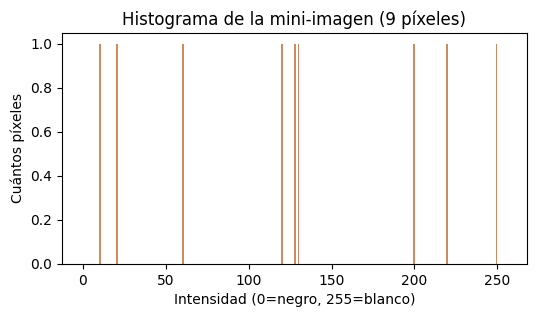

In [6]:
# Volvemos a la mini-imagen 3x3 de la Parte 1 (9 píxeles en total).
# El metodo .ravel() "aplana" la tabla en una sola fila de números, para poder contarlos:
print("Los 9 valores de la mini-imagen, en fila:", mini.ravel())

# np.unique con return_counts=True nos dice qué valores hay y cuántas veces aparece cada uno:
valores, cuentas = np.unique(mini, return_counts=True)
for v, c in zip(valores, cuentas):        # recorremos cada valor con su conteo
    print(f"  el tono {v:3d} aparece {c} vez/veces")

# Un histograma es justamente ese conteo, dibujado como barras:
plt.figure(figsize=(6, 3))
plt.hist(mini.ravel(), bins=256, range=(0, 255), color="#D08A5E")
plt.title("Histograma de la mini-imagen (9 píxeles)")
plt.xlabel("Intensidad (0=negro, 255=blanco)")
plt.ylabel("Cuántos píxeles")
plt.show()

Con 9 píxeles casi no hay barras. Ahora **el mismo gráfico sobre la imagen real**, donde
hay miles de píxeles y el histograma toma forma.

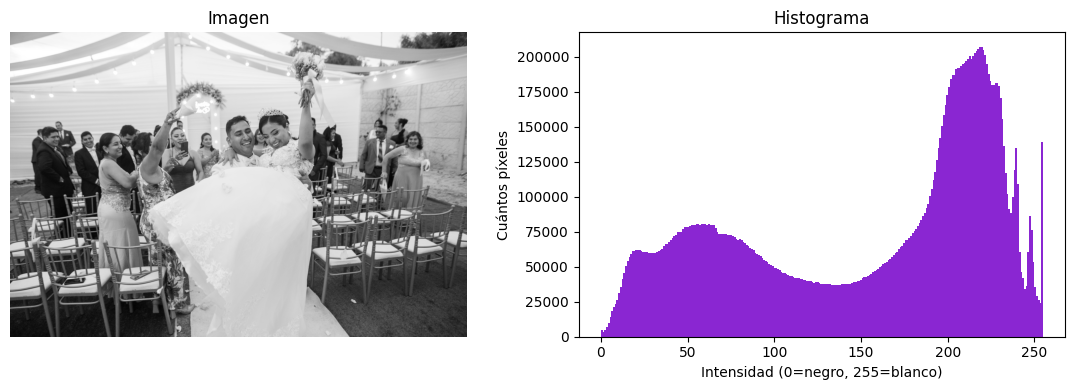

In [7]:
# Dibujamos la imagen y su histograma, lado a lado, para compararlos:
plt.figure(figsize=(11, 4))

# --- Izquierda: la imagen ---
plt.subplot(1, 2, 1)                       # (1 fila, 2 columnas, posición 1 = izquierda)
plt.imshow(work_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Imagen")
plt.axis("off")

# --- Derecha: su histograma ---
plt.subplot(1, 2, 2)                       # posición 2 = derecha
# bins=256 -> una barra por cada tono posible (0..255). range=(0,255) -> el eje X va de 0 a 255.
plt.hist(work_gray.ravel(), bins=256, range=(0, 255), color="#8A26D2")
plt.title("Histograma")
plt.xlabel("Intensidad (0=negro, 255=blanco)")
plt.ylabel("Cuántos píxeles")

plt.tight_layout()                         # ordena los dos gráficos para que no se encimen
plt.show()

**Cómo leerlo:** barras amontonadas a la **izquierda** → imagen **oscura**; a la
**derecha** → **clara**; todas juntas en el **centro** → **bajo contraste** (se ve plana).

---
## Parte 4 · Brillo y contraste

La fórmula es: **`salida = contraste × imagen + brillo`**

- **Brillo** = *sumar* (o restar) un número a cada píxel → aclara (u oscurece) toda la imagen.
- **Contraste** = *multiplicar* por un factor → separa más los tonos claros de los oscuros.

**Primero con la mini-imagen**, para ver la cuenta con números concretos.

In [9]:
# Partimos de la mini-imagen. La pasamos a int16 (enteros más grandes) para que,
# al sumar, PODAMOS ver valores por encima de 255 antes de recortarlos.
mini_grande = mini.astype(np.int16)          # copia de la mini-imagen con más "espacio"

suma = mini_grande + 60                        # sumamos 60 de brillo a CADA píxel

print("Original:")
print(mini_grande)
print("\nDespués de +60 (¡ojo, algunos pasan de 255!):")
print(suma)                                    # verás valores como 280, 310, etc.


Original:
[[ 20 120 220]
 [ 60 130 200]
 [ 10 128 250]]

Después de +60 (¡ojo, algunos pasan de 255!):
[[ 80 180 280]
 [120 190 260]
 [ 70 188 310]]


In [10]:

# el metodo np.clip "recorta": todo lo mayor que 255 lo deja en 255, todo lo menor que 0 en 0.
recortada = np.clip(suma, 0, 255)
print("\nDespués de recortar a 0..255 (correcto):")
print(recortada)


Después de recortar a 0..255 (correcto):
[[ 80 180 255]
 [120 190 255]
 [ 70 188 255]]


¿Ves los valores que se pasaron de 255 y cómo el recorte los deja justo en 255? Ese recorte
es imprescindible: sin él, la imagen se rompe (lo vemos en la Parte 5).

Ahora **el mismo ajuste sobre la imagen real**. Usamos una función de OpenCV que aplica la
fórmula **y recorta**, todo de una vez.

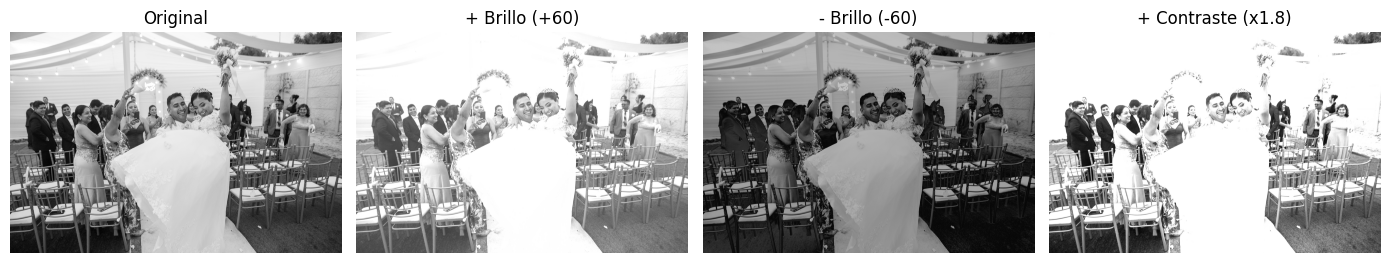

In [11]:
# Esta función permite cambiar el contraste y el brillo de una imagen.
def ajustar(img, contraste=1.0, brillo=0): # Definimos la funcion
    # El metodo cv2.convertScaleAbs aplica:  salida = |contraste*img + brillo|  y recorta a 0..255.
    #   alpha = contraste (multiplica)   |   beta = brillo (suma)
    return cv2.convertScaleAbs(img, alpha=contraste, beta=brillo)


# Creamos cuatro versiones para comparar (cambia los números y vuelve a ejecutar para probar):
mas_brillo    = ajustar(work_gray, contraste=1.0, brillo=60)    # +60 a cada píxel  -> aclara
menos_brillo  = ajustar(work_gray, contraste=1.0, brillo=-60)   # -60 a cada píxel  -> oscurece
mas_contraste = ajustar(work_gray, contraste=1.8, brillo=0)     # x1.8              -> más contraste

# Las mostramos en una fila de 4 imágenes:
imagenes = [work_gray, mas_brillo, menos_brillo, mas_contraste]
titulos  = ["Original", "+ Brillo (+60)", "- Brillo (-60)", "+ Contraste (x1.8)"]

fig, ejes = plt.subplots(1, 4, figsize=(14, 4))   # 1 fila, 4 columnas de gráficos
# zip empareja cada "hueco" de gráfico (eje) con su imagen y su título:
for eje, im, t in zip(ejes, imagenes, titulos):
    eje.imshow(im, cmap="gray", vmin=0, vmax=255)  # misma escala 0..255 en todas (comparación justa)
    eje.set_title(t)
    eje.axis("off")
plt.tight_layout()
plt.show()

---
## Parte 5 · Por qué el recorte es obligatorio

Un píxel guarda un entero de **8 bits**: solo llega hasta 255. Si sumas sin cuidado y te
pasas, el número **no** se queda en 255: "da la vuelta" y reinicia desde 0. Veámoslo con
un solo número para que quede clarísimo.

In [12]:
# Tomamos un píxel claro de valor 200 y le sumamos 100. Debería dar 255 (el máximo).
valor = np.uint8(200)                     # un píxel de tipo uint8 (0..255)
print("200 como uint8:", valor)

# CUIDADO: en uint8, 200 + 100 NO da 300 ni 255. "Da la vuelta":
mal = valor + np.uint8(100)               # suma dentro del tipo uint8
print("200 + 100 en uint8 (mal):", mal, " <- ¡se convirtió en un tono oscuro!")
# Nota: al ejecutar esta celda, Colab puede mostrar un aviso "overflow
#       encountered". NO es un error: es justamente la advertencia de que el
#       número se pasó de 255 y dio la vuelta. Es lo que queremos demostrar aquí.

# La forma correcta: calcular con enteros grandes y LUEGO recortar a 255.
bien = np.clip(int(valor) + 100, 0, 255)  # int(...) evita el problema; clip recorta a 255
print("200 + 100 recortado (bien):", bien)

200 como uint8: 200
200 + 100 en uint8 (mal): 44  <- ¡se convirtió en un tono oscuro!
200 + 100 recortado (bien): 255


/tmp/ipykernel_2835/2155332198.py:6: RuntimeWarning: overflow encountered in scalar add
  mal = valor + np.uint8(100)               # suma dentro del tipo uint8


> **Conclusión:** siempre que ajustes brillo o contraste, deja que OpenCV recorte por ti con la función
> `cv2.convertScaleAbs` (lo que ya hiciste en la Parte 4). Nunca sumes "a mano" sobre `uint8`.

---
## Parte 6 · Ecualización del histograma

La ecualización **estira** las intensidades para que ocupen todo el rango 0–255. Es una
forma **automática** de mejorar el contraste: no eliges ningún número, la función lo hace sola.

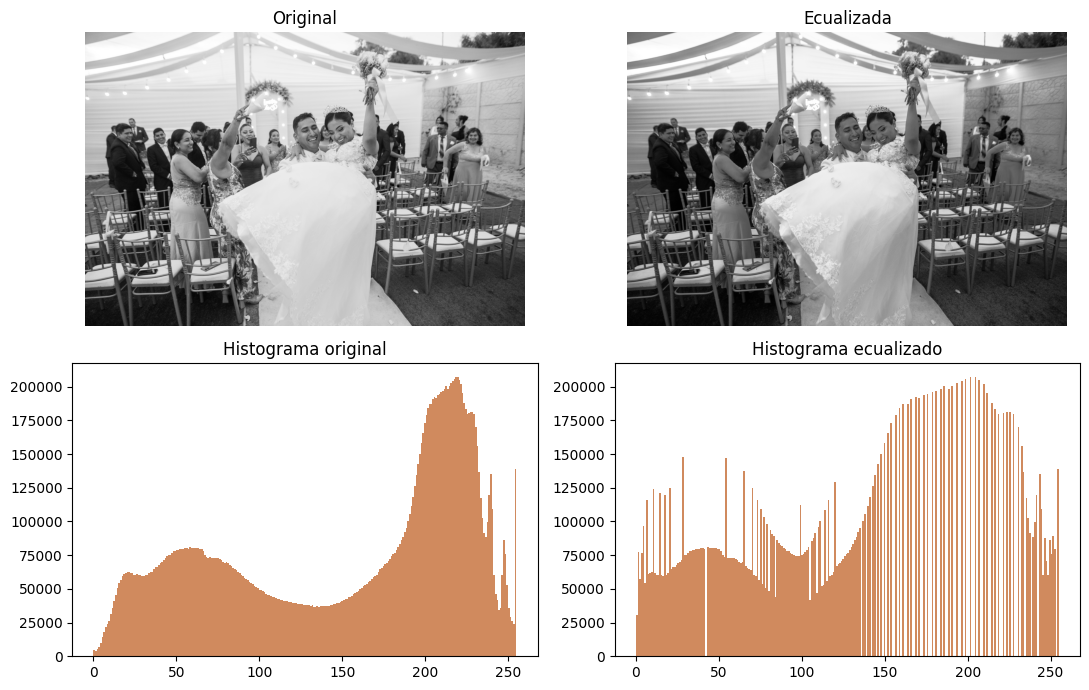

In [13]:
# cv2.equalizeHist hace todo el trabajo sobre la imagen en grises:
ecualizada = cv2.equalizeHist(work_gray)

# Comparamos en una cuadrícula 2x2: arriba las imágenes, abajo sus histogramas.
fig, ejes = plt.subplots(2, 2, figsize=(11, 7))     # 2 filas x 2 columnas

# Fila de arriba: imagen original vs ecualizada
ejes[0,0].imshow(work_gray, cmap="gray", vmin=0, vmax=255)
ejes[0,0].set_title("Original"); ejes[0,0].axis("off")
ejes[0,1].imshow(ecualizada, cmap="gray", vmin=0, vmax=255)
ejes[0,1].set_title("Ecualizada"); ejes[0,1].axis("off")

# Fila de abajo: histograma original (apretado) vs ecualizado (estirado)
ejes[1,0].hist(work_gray.ravel(),  bins=256, range=(0,255), color="#D08A5E")
ejes[1,0].set_title("Histograma original")
ejes[1,1].hist(ecualizada.ravel(), bins=256, range=(0,255), color="#D08A5E")
ejes[1,1].set_title("Histograma ecualizado")

plt.tight_layout()
plt.show()

Fíjate cómo el histograma de la derecha se **estira** para cubrir todo el ancho: por eso la
imagen gana contraste. Es muy útil en radiografías o fotos con poca luz.

---
## Parte 7 · Umbralización: separar objeto y fondo

Umbralizar es fijar un **valor de corte (umbral)**: cada píxel se vuelve **blanco** si lo
supera, o **negro** si no. Convierte la imagen en blanco y negro puro.

**Primero con la mini-imagen**, para ver la regla píxel por píxel.

In [14]:
# Regla: si el valor > 127 -> 255 (blanco); si no -> 0 (negro).
umbral = 127
print("Mini-imagen original:")
print(mini)

# (mini > umbral) da una tabla de True/False. Multiplicar por 255 convierte
# True->255 (blanco) y False->0 (negro). astype(uint8) lo deja como imagen.
mini_binaria = ((mini > umbral) * 255).astype(np.uint8)
print(f"\nMini-imagen umbralizada con corte {umbral} (255=blanco, 0=negro):")
print(mini_binaria)

Mini-imagen original:
[[ 20 120 220]
 [ 60 130 200]
 [ 10 128 250]]

Mini-imagen umbralizada con corte 127 (255=blanco, 0=negro):
[[  0   0 255]
 [  0 255 255]
 [  0 255 255]]


Cada número se volvió 0 o 255 según si superaba 127. Ahora sobre la imagen real, y además
comparamos el umbral fijo con **Otsu**, que elige el mejor corte automáticamente.

Umbral elegido por Otsu: 136.0  (compáralo con el 127 fijo)


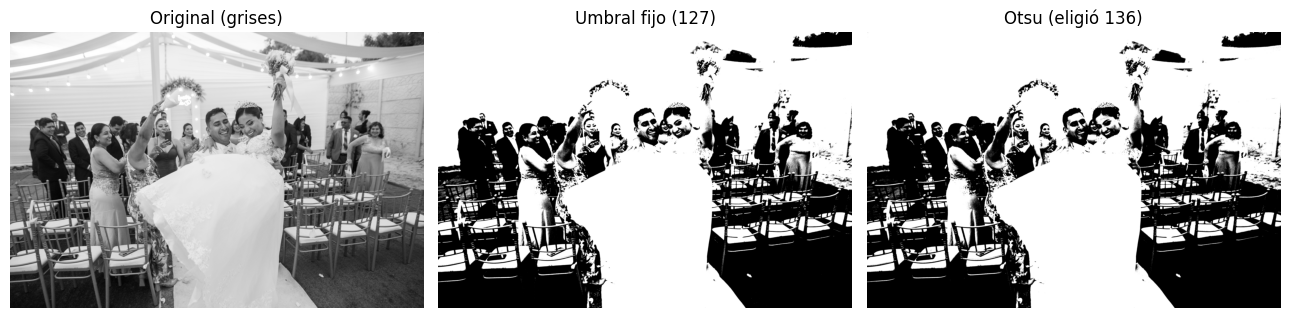

In [15]:
# --- Umbral FIJO (siempre 127) ---
# cv2.threshold devuelve dos cosas; el primer valor no lo usamos, por eso el "_".
_, binaria_fija = cv2.threshold(
    work_gray,          # 1. Imagen de entrada
    127,                # 2. Umbral
    255,                # 3. Valor máximo
    cv2.THRESH_BINARY   # 4. Tipo de transformación
)

# --- Umbral de OTSU (automático) ---
# Pasamos 0 como umbral y añadimos la constante THRESH_OTSU: OpenCV analiza el histograma y ELIGE el mejor.
# Aquí SÍ guardamos el primer valor: es el umbral que Otsu decidió.
umbral_otsu, binaria_otsu = cv2.threshold(
    work_gray,                              # 1. Imagen en escala de grises
    0,                                      # 2. Umbral inicial (Otsu lo calcula automáticamente)
    255,                                    # 3. Valor máximo: blanco
    cv2.THRESH_BINARY + cv2.THRESH_OTSU     # 4. Binarización usando Otsu
)
print("Umbral elegido por Otsu:", umbral_otsu, " (compáralo con el 127 fijo)")

# Comparamos las tres versiones:
imagenes = [work_gray, binaria_fija, binaria_otsu]
titulos  = ["Original (grises)", "Umbral fijo (127)", f"Otsu (eligió {int(umbral_otsu)})"]

fig, ejes = plt.subplots(1, 3, figsize=(13, 4))
for eje, im, t in zip(ejes, imagenes, titulos):
    eje.imshow(im, cmap="gray", vmin=0, vmax=255)
    eje.set_title(t)
    eje.axis("off")
plt.tight_layout()
plt.show()

---
## Parte 8 · Normalización: preparar la imagen para un modelo

Este es el puente hacia el resto del curso. Las redes neuronales **no** trabajan bien con
valores de 0 a 255; esperan números pequeños (0 a 1) o centrados en 0. Convertir la imagen
a ese rango se llama **normalizar**, y es obligatorio antes de entrenar cualquier modelo.

**Primero con la mini-imagen**, para ver cómo cambian los números.

In [ ]:
# 1) NORMALIZAR a rango [0, 1]:
# Usamos el metodo .astype(np.float32) convierte los enteros a decimales (para poder dividir).
# Dividir entre 255.0 lleva el rango 0..255 al rango 0.0..1.0.
mini_norm = mini.astype(np.float32) / 255.0
print("Mini original (0..255):")
print(mini)
print("\nMini normalizada (0..1):")
print(np.round(mini_norm, 2))              # np.round: redondea a 2 decimales para leer mejor

Mini original (0..255):
[[ 20 120 220]
 [ 60 130 200]
 [ 10 128 250]]

Mini normalizada (0..1):
[[0.08 0.47 0.86]
 [0.24 0.51 0.78]
 [0.04 0.5  0.98]]


El mismo número (por ejemplo 128) pasó a ser ~0.50. La imagen es la misma; solo cambió la
**escala**. Ahora aplicamos los dos niveles (normalizar y estandarizar) a la imagen real.

Antes   -> min: 0 max: 255 tipo: uint8
Después -> min: 0.0 max: 1.0 tipo: float32

Estandarizada -> media ~ 0.0 | desviación ~ 1.0


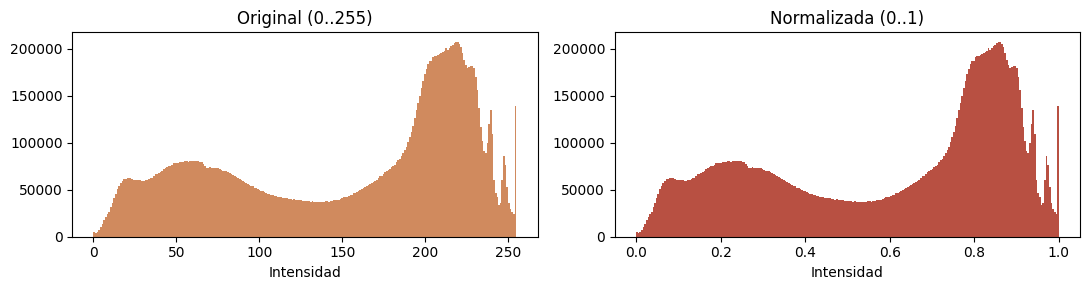

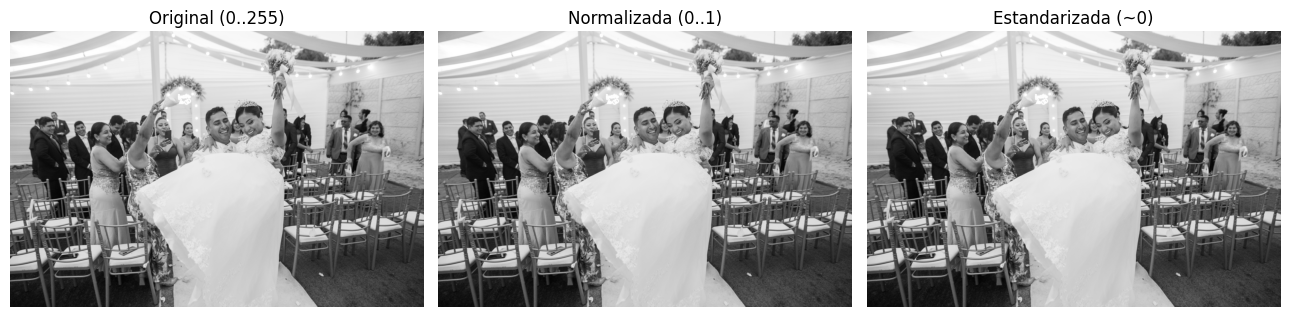

In [16]:
# 1) Normalización a [0, 1] sobre la imagen real:
img_float = work_gray.astype(np.float32) / 255.0
print("Antes   -> min:", work_gray.min(), "max:", work_gray.max(), "tipo:", work_gray.dtype)
print("Después -> min:", round(float(img_float.min()), 3),
      "max:", round(float(img_float.max()), 3), "tipo:", img_float.dtype)

# 2) Estandarización: dejar los datos "centrados en 0".
media = img_float.mean()                    # brillo promedio (un solo número)
desv  = img_float.std()                     # cuánto varían los píxeles (desviación estándar)

# A cada píxel le restamos la media y lo dividimos por la desviación.
# El "+ 1e-8" (0.00000001) evita dividir entre cero por seguridad.
img_estandarizada = (img_float - media) / (desv + 1e-8)

# Tras estandarizar, la media queda ~0 y la desviación ~1:
print("\nEstandarizada -> media ~", round(float(img_estandarizada.mean()), 3),
      "| desviación ~", round(float(img_estandarizada.std()), 3))

# Mostramos los histogramas para VER el cambio de escala (el eje X pasa de 0..255 a 0..1):
fig, ejes = plt.subplots(1, 2, figsize=(11, 3))
ejes[0].hist(work_gray.ravel(), bins=256, range=(0, 255), color="#D08A5E")
ejes[0].set_title("Original (0..255)"); ejes[0].set_xlabel("Intensidad")
ejes[1].hist(img_float.ravel(), bins=256, range=(0, 1), color="#B85042")
ejes[1].set_title("Normalizada (0..1)"); ejes[1].set_xlabel("Intensidad")
plt.tight_layout(); plt.show()

# Mostramos las 3 versiones como imagen. Clave: NO fijamos vmin/vmax, así cada una
# se dibuja con su propia escala y se nota la diferencia de rango de valores.
fig, ejes = plt.subplots(1, 3, figsize=(13, 4))
ejes[0].imshow(work_gray, cmap="gray"); ejes[0].set_title("Original (0..255)"); ejes[0].axis("off")
ejes[1].imshow(img_float, cmap="gray"); ejes[1].set_title("Normalizada (0..1)"); ejes[1].axis("off")
ejes[2].imshow(img_estandarizada, cmap="gray"); ejes[2].set_title("Estandarizada (~0)"); ejes[2].axis("off")
plt.tight_layout(); plt.show()

**¿Por qué importa?** Cuando en la Unidad 2 entrenemos una red, este paso será rutina: la
imagen entra como números pequeños y centrados para que el entrenamiento sea estable. Hoy ya
sabes qué significa y por qué se hace.

---
## Ejercicio de la clase — TU TURNO

**Objetivo:** diagnosticar y mejorar una imagen usando lo de hoy. Completa cada paso siguiendo
los comentarios. Puedes usar la imagen de ejemplo o subir la tuya (Parte 2).

1. Muestra el **histograma** de tu imagen y di si es oscura, clara o de bajo contraste.
2. Según tu diagnóstico, **mejórala**: si es oscura/clara ajusta el brillo; si es plana sube
   el contraste o ecualiza. Muestra el antes y el después.
3. Aplica **umbralización de Otsu** a tu imagen mejorada.
4. Responde por escrito (celda de abajo): ¿por qué una red neuronal necesita la imagen
   normalizada a 0–1 en lugar de 0–255?

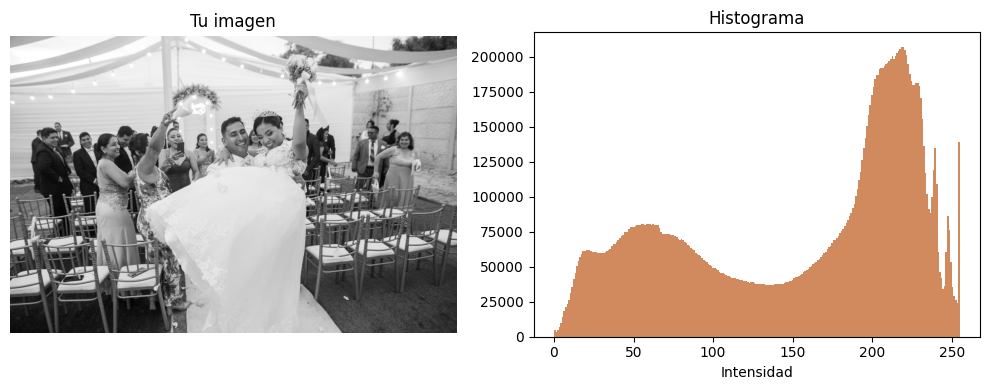

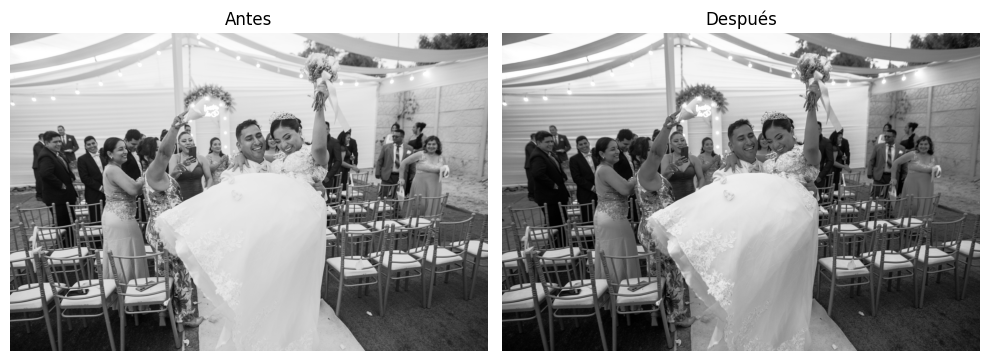

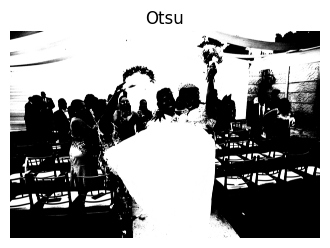

In [29]:
# TU TURNO — completa cada paso

# ---------- Paso 1: histograma y diagnóstico ----------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(work_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Tu imagen"); plt.axis("off")
plt.subplot(1, 2, 2); plt.hist(work_gray.ravel(), bins=256, range=(0,255), color="#D08A5E")
plt.title("Histograma"); plt.xlabel("Intensidad")
plt.tight_layout(); plt.show()

# Escribe tu diagnóstico aquí (borra los puntos y completa):
# Mi imagen es clara  por que el sesgo en la barra de histograma se concentra entre el rango 200 a 255
# ---------- Paso 2: mejora (elige UNA opción y cambia el número) ----------
# Si es OSCURA -> brillo positivo.  Si es CLARA -> brillo negativo.
# Si es PLANA  -> sube el contraste (>1), o usa la línea de ecualizar de abajo.
mejorada = ajustar(work_gray, contraste=1.0, brillo=-60)   # <-- cambia estos números
#  observacion :si no se usa la ecualizacion se debe comprobar el rango permitido para que la
# imagen no se distorsione los pixeles  y se pierda la imagen. ejemplo ; probe de un rango -40 a -60
# se mantiene visibilidad de la imagen correctamente , pasando de -70 a -100 , se nota una distorsion de los pixeles.
# alternativa (quita el # para probar la ecualización):
mejorada = cv2.equalizeHist(work_gray)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(work_gray, cmap="gray", vmin=0, vmax=255); ax[0].set_title("Antes");   ax[0].axis("off")
ax[1].imshow(mejorada,  cmap="gray", vmin=0, vmax=255); ax[1].set_title("Después"); ax[1].axis("off")
plt.tight_layout(); plt.show()

# ---------- Paso 3: umbralización de Otsu sobre tu imagen mejorada ----------
_, binaria_ej = cv2.threshold(mejorada, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.figure(figsize=(4, 4)); plt.imshow(binaria_ej, cmap="gray", vmin=0, vmax=255)
plt.title("Otsu"); plt.axis("off"); plt.show()

### Paso 4 — Tu respuesta (escribe aquí)

**¿Por qué una red neuronal necesita la imagen normalizada a 0–1 y no en 0–255?**

*(De acuerdo a la clase, a menor escala, mejor es el procesamiento de pixeles , lo cual permite estabilidad del entrenamiento y su rendimiento ayuda a las funciones de activacion, donde el aprendizaje es mas fluido, tambien con lleva a menor uso de recurso computacional. )*

---
### Cierre de la Clase 2

Hoy pasaste de **entender** la imagen como números a **operar** sobre ellos: histograma,
brillo, contraste, ecualización, umbralización y —el puente hacia lo que viene—
**normalización**.

**Próxima clase:** el filtrado y la convolución — la misma operación que, más adelante, una
red neuronal convolucional aprende por sí sola.